# 5장 1강: 시퀀스-투-시퀀스 구조의 이해
## 3. PyTorch를 활용한 LSTM 기반 영-한 단어 번역 실습

### 3.1 인코더(Encoder) 구현

In [2]:
import torch
import torch.nn as nn

class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size):
        super().__init__()

        # 임베딩 레이어
        self.embedding = nn.Embedding(input_size, embed_size)

        #LSTM 레이어
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded) # (hidden, cell) -> 컨텍스트 벡터
        return hidden, cell

### 3.2 디코더(Decoder) 구현

In [4]:
class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size):
        super().__init__()

        # 임베딩 레이어
        self.embedding = nn.Embedding(output_size, embed_size)

        # LSTM 레이어
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

        # 출력층 (분류기)
        self.output = nn.Linear(hidden_size, output_size)

    # hidden_state -> 초기값은 인코더의 컨텍스트 벡터
    def forward(self, x, hidden_state):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, hidden_state)
        prediction = self.output(outputs.squeeze(1)) #3 3차원 벡터를 2차원 벡터로(batch, output_size)

        return prediction, (hidden, cell)

### 3.3 모델 완성 및 테스트 (데이터 전처리, 학습, 추론)

c:\Users\boomd\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\torch\autograd\graph.py:979: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


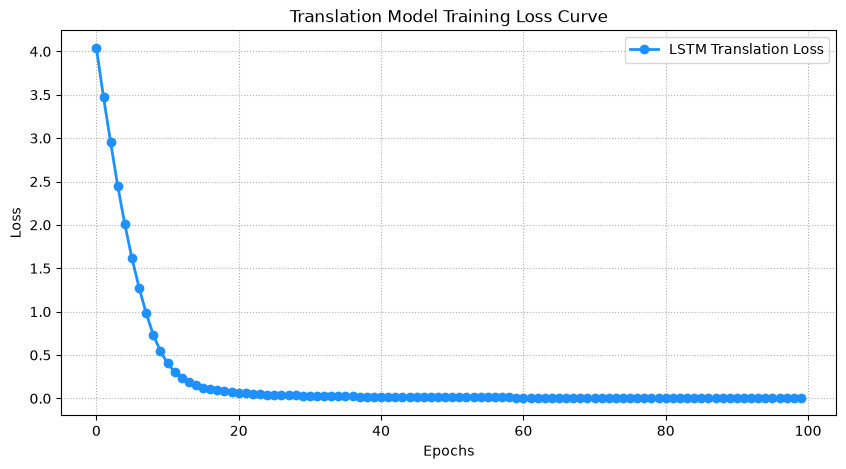


--- [추론 테스트] 번역 결과 확인 ---
입력(ENG): hello   ===>  출력(KOR): 안녕
입력(ENG): car     ===>  출력(KOR): 차
입력(ENG): cat     ===>  출력(KOR): 고양이
입력(ENG): dog     ===>  출력(KOR): 개
입력(ENG): sun     ===>  출력(KOR): 태양


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim

# ==========================================
# 데이터 준비 및 어휘 사전(Vocabulary) 구축
# ==========================================
pairs = [
    ("hello", "안녕"),
    ("car", "차"),
    ("cat", "고양이"),
    ("dog", "개"),
    ("sun", "태양")
]

# 특수 토큰 설정 (<pad>: 패딩, <sos>: 시작 신호, <eos>: 종료 신호)
src_words = ["<pad>"] + list(sorted(list(set([p[0] for p in pairs]))))
tgt_words = ["<pad>", "<sos>", "<eos>"] + list(sorted(list(set([p[1] for p in pairs]))))

# 인덱스 변환 맵 생성
src_w2i = {w: i for i, w in enumerate(src_words)}
src_i2w = {i: w for i, w in enumerate(src_words)}
tgt_w2i = {w: i for i, w in enumerate(tgt_words)}
tgt_i2w = {i: w for i, w in enumerate(tgt_words)}

def encode_src(sent): return [src_w2i[sent]]
def encode_tgt(sent): return [tgt_w2i["<sos>"]] + [tgt_w2i[sent]] + [tgt_w2i["<eos>"]]


embed_size = 16
hidden_size = 16

# 모델 선언 및 지정된 디바이스로 할당
encoder = EncoderLSTM(len(src_words), embed_size, hidden_size)
decoder = DecoderLSTM(len(tgt_words), embed_size, hidden_size)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.01)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 텐서 데이터 변환 후 가속 디바이스로 연동
src_tensors = [torch.tensor([encode_src(p[0])], dtype=torch.long) for p in pairs]
tgt_tensors = [torch.tensor([encode_tgt(p[1])], dtype=torch.long) for p in pairs]

# ==========================================
# 모델 학습 루프 실행 (교사 강요 기법 적용)
# ==========================================
losses = []

for epoch in range(100):
    epoch_loss = 0
    for src_t, tgt_t in zip(src_tensors, tgt_tensors):
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        # [인코더] 컨텍스트 벡터 추출
        enc_hidden, enc_cell = encoder(src_t)
        
        # [디코더] 초기 상태를 인코더의 출력값으로 연동
        decoder_hidden_state = (enc_hidden, enc_cell)
        decoder_input = tgt_t[:, 0:1]  # 첫 시작 단어는 <sos> 토큰
        
        loss = 0
        for t in range(1, tgt_t.size(1)):
            prediction, decoder_hidden_state = decoder(decoder_input, decoder_hidden_state)
            target = tgt_t[:, t]
            loss += criterion(prediction, target)
            
            # [교사 강요] 모델의 예측값 대신 실제 정답 데이터를 다음 시점의 입력으로 강제 설정
            decoder_input = tgt_t[:, t:t+1]
            
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
        
        epoch_loss += loss.item()
        
    losses.append(epoch_loss / len(pairs))

# ==========================================
# 학습 오차(Loss) 하강 곡선 시각화
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(losses, color='dodgerblue', linewidth=2, linestyle='-', marker='o', label='LSTM Translation Loss')
plt.title('Translation Model Training Loss Curve', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

# ==========================================
# 모델 추론 및 번역 성능 최종 테스트
# ==========================================
print("\n--- [추론 테스트] 번역 결과 확인 ---")
with torch.no_grad():
    for src_t, p in zip(src_tensors, pairs):
        enc_hidden, enc_cell = encoder(src_t)
        decoder_hidden_state = (enc_hidden, enc_cell)
        
        # 입력용 시작 토큰 생성 및 디바이스 연동
        decoder_input = torch.tensor([[tgt_w2i["<sos>"]]], dtype=torch.long)
        translated_sentence = []
        
        for _ in range(5):  # 출력 최대 길이 제한
            prediction, decoder_hidden_state = decoder(decoder_input, decoder_hidden_state)
            predicted_idx = prediction.argmax(1).item()  # 최고 점수를 얻은 토큰 인덱스 선택
            
            if predicted_idx == tgt_w2i["<eos>"]:
                break
                
            translated_sentence.append(tgt_i2w[predicted_idx])
            
            # 자가 예측(기본 추론): 모델이 직접 예측한 단어를 다음 시점의 입력값 및 디바이스 설정으로 갱신
            decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long)
            
        print(f"입력(ENG): {p[0]:6s}  ===>  출력(KOR): {' '.join(translated_sentence)}")